 PyTorch Lab: Activation Functions and the Update Rule

**Format:** Google Colab | **Level:** introductory deep learning | **Runtime:** CPU

> **Big question:** How does the activation function decide whether a one-neuron model can learn, and how fast it learns?

## Learning outcomes
By the end of the lab, students will be able to:

1. compute a perceptron's weighted sum, activation, loss, and weight update;
2. use PyTorch autograd to inspect activation-function gradients;
3. explain why the threshold/step function cannot be trained by ordinary gradient descent; and
4. compare sigmoid and tanh at the center and in saturated regions.

## 60-minute run of show

| Time | Mode | Task |
|---:|---|---|
| 0-5 min | Launch | Predict which activation learns fastest |
| 5-15 min | Teacher demo 1 | Plot step, sigmoid, tanh and their gradients |
| 15-25 min | Student activity 1 | Build an activation-gradient probe |
| 25-35 min | Teacher demo 2 | Trace one sigmoid update with autograd |
| 35-50 min | Student activity 2 | Implement and test one update |
| 50-57 min | Pair challenge | Investigate saturation and step size |
| 57-60 min | Exit ticket | Explain the result in words |



## 0. Launch question (0-5 min)

A single neuron computes

$$z=wx+b, \qquad \hat y=f(z), \qquad L=\tfrac12(\hat y-y)^2.$$

Gradient descent updates the weight using

$$w_{new}=w_{old}-\alpha\frac{\partial L}{\partial w}, \qquad\frac{\partial L}{\partial w}=(\hat y-y)f'(z)x.$$

**Predict before running code:** Which activation will make the largest update near $z=0$: step, sigmoid, or tanh? Give one reason.

Your prediction: `____________________________________________________________`

In [ ]:
import math
import torch
import matplotlib.pyplot as plt

torch.manual_seed(7)
torch.set_printoptions(precision=6, sci_mode=False)

print(torch.__version__)

2.11.0+cu128


## 1. outputs and gradients (5-15 min)

Run the next cell and read each row vertically: the top plot is $f(z)$ and the bottom plot is $f'(z)$.



- The step function returns a decision, but its slope is zero almost everywhere and undefined at $z=0$. A PyTorch comparison such as `z >= 0` is disconnected from autograd.
- Sigmoid is smooth and has derivative $\sigma(z)(1-\sigma(z))$, with maximum $0.25$.
- Tanh is smooth and has derivative $1-\tanh^2(z)$, with maximum $1$.
- Both smooth functions saturate: far from zero, their gradients become small.

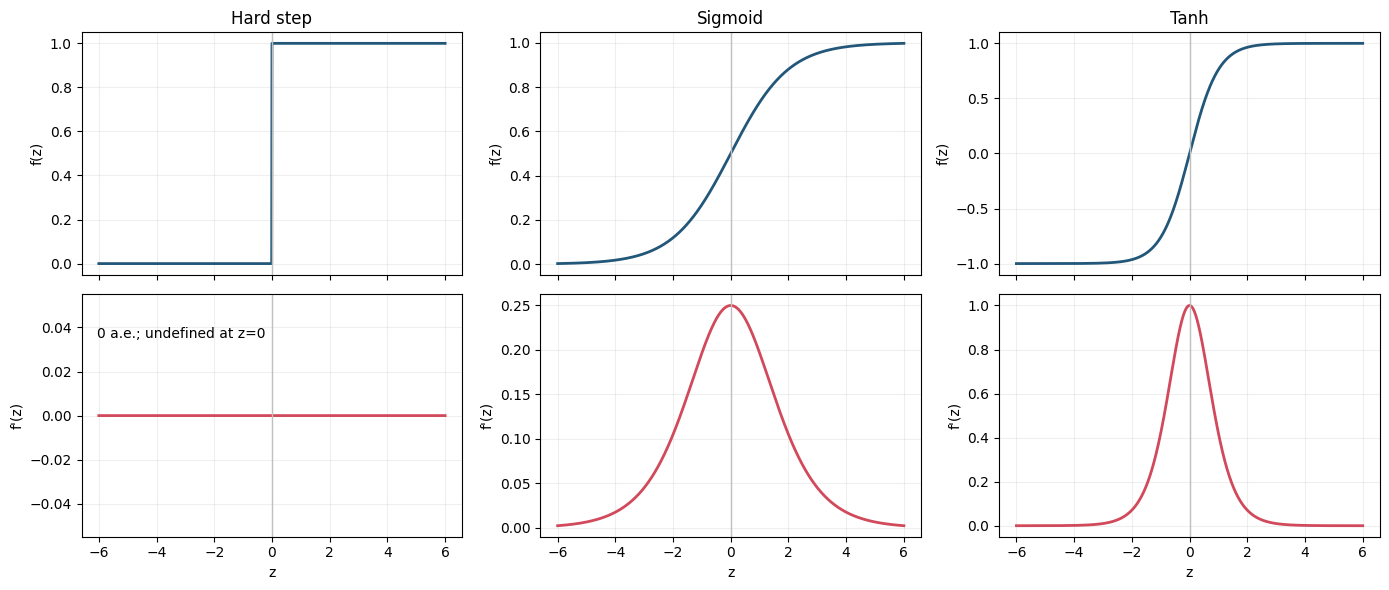

At z=0: sigmoid'=0.25, tanh'=1.00
Hard-step output requires grad? False


In [ ]:
z = torch.linspace(-6, 6, 1201, requires_grad=True)

step_y = (z >= 0).float()
sigmoid_y = torch.sigmoid(z)
tanh_y = torch.tanh(z)

step_grad = torch.zeros_like(z)
sigmoid_grad = torch.autograd.grad(sigmoid_y.sum(), z)[0]
tanh_grad = torch.autograd.grad(tanh_y.sum(), z)[0]

names = ["Hard step", "Sigmoid", "Tanh"]
outputs = [step_y.detach(), sigmoid_y.detach(), tanh_y.detach()]
grads = [step_grad.detach(), sigmoid_grad.detach(), tanh_grad.detach()]

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for col, (name, out, grad) in enumerate(zip(names, outputs, grads)):
    axes[0, col].plot(z.detach(), out, color="#22577A", linewidth=2)
    axes[0, col].set_title(name)
    axes[0, col].set_ylabel("f(z)")
    axes[1, col].plot(z.detach(), grad, color="#D1495B", linewidth=2)
    axes[1, col].set_ylabel("f'(z)")
    axes[1, col].set_xlabel("z")
    for ax in axes[:, col]:
        ax.axvline(0, color="0.75", linewidth=1)
        ax.grid(alpha=0.2)
axes[1, 0].text(0.04, 0.82, "0 a.e.; undefined at z=0", transform=axes[1, 0].transAxes)
plt.tight_layout()
plt.show()

center = len(z) // 2
print(f"At z=0: sigmoid'={sigmoid_grad[center].item():.2f}, tanh'={tanh_grad[center].item():.2f}")
print("Hard-step output requires grad?", step_y.requires_grad)

### Check for understanding

Ask students to answer aloud:

1. Why can the step function make a decision but not learn through ordinary backpropagation?
2. Where are sigmoid and tanh most sensitive to a change in $z$?
3. What happens to the gradient when $|z|$ becomes large?

## 2. Student activity 1: activation-gradient probe (15-25 min)

Complete `student_probe` so that it returns `(activation, gradient)` for one scalar input.

Requirements:

- support `name == "sigmoid"` and `name == "tanh"`;
- create `z` with `requires_grad=True`;
- use `torch.autograd.grad`;
- return ordinary Python numbers using `.item()`.

Then set `A1_READY = True` and run the tests. **Do not use the derivative formulas directly.**

In [ ]:
A1_READY = True  # Change to True after completing the TODOs.

def student_probe(name, value):
    z = torch.tensor(float(value), requires_grad=True)

    if name == "sigmoid":
        activation = torch.sigmoid(z)
    elif name == "tanh":
        activation = torch.tanh(z)
    else:
        raise ValueError("name must be 'sigmoid' or 'tanh'")

    gradient = torch.autograd.grad(activation, z)[0]

    return activation.item(), gradient.item()hbb


if not A1_READY:
    print("Complete student_probe, change A1_READY to True, and run again.")
else:
    s0 = student_probe("sigmoid", 0.0)
    t0 = student_probe("tanh", 0.0)
    assert math.isclose(s0[0], 0.5, abs_tol=1e-6)
    assert math.isclose(s0[1], 0.25, abs_tol=1e-6)
    assert math.isclose(t0[0], 0.0, abs_tol=1e-6)
    assert math.isclose(t0[1], 1.0, abs_tol=1e-6)
    print("Tests passed!")
    for value in [-4.0, 0.0, 4.0]:
        print(value, student_probe("sigmoid", value), student_probe("tanh", value))

SyntaxError: invalid syntax (1907274921.py, line 15)

### Activity 1 evidence table

Use your function at $z=-4,0,4$ and record the gradients to three decimals.

| $z$ | sigmoid gradient | tanh gradient | Which is larger? |
|---:|---:|---:|---|
| -4 |  |  |  |
| 0 |  |  |  |
| 4 |  |  |  |

**One-sentence conclusion:** `________________________________________________________`

## 3. Teacher demo: trace one sigmoid update (25-35 min)

We reproduce the lecture case $x=2$, $w=1$, $b=0$, $y=0$, and $\alpha=0.5$. Pause after each printed line and connect it to the chain rule.

Expected path:

$$x \rightarrow z \rightarrow \hat y \rightarrow L \rightarrow \frac{\partial L}{\partial w} \rightarrow w_{new}.$$

In [ ]:
from matplotlib.patches import Circle, FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(-0.6, 5)
ax.axis("off")

def circle_node(xy, text, color):
    node = Circle(xy, 0.55, facecolor=color, edgecolor="#17324D", linewidth=2)
    ax.add_patch(node)
    ax.text(*xy, text, ha="center", va="center", fontsize=12, fontweight="bold")

def box_node(xy, width, text, color):
    x0, y0 = xy[0] - width / 2, xy[1] - 0.55
    node = FancyBboxPatch(
        (x0, y0), width, 1.1,
        boxstyle="round,pad=0.08,rounding_size=0.12",
        facecolor=color, edgecolor="#17324D", linewidth=2,
    )
    ax.add_patch(node)
    ax.text(*xy, text, ha="center", va="center", fontsize=11, fontweight="bold")

def arrow(start, end, label=None, label_xy=None, color="#17324D"):
    ax.add_patch(FancyArrowPatch(
        start, end, arrowstyle="-|>", mutation_scale=18,
        linewidth=2, color=color, shrinkA=4, shrinkB=4,
    ))
    if label:
        lx, ly = label_xy or ((start[0] + end[0]) / 2, (start[1] + end[1]) / 2 + 0.25)
        ax.text(lx, ly, label, ha="center", va="center", fontsize=10, color=color)

# Forward-pass nodes with the lecture values.
circle_node((1.0, 3.4), "x = 2", "#D8F3DC")
circle_node((1.0, 1.3), "b = 0", "#FFF3BF")
box_node((3.8, 2.5), 2.2, "Weighted sum\nz = wx + b = 2", "#DDEBFF")
box_node((6.5, 2.5), 1.7, "Sigmoid\nσ(z)", "#E5DBFF")
circle_node((9.0, 2.5), "ŷ =\n0.880797", "#FFD8A8")
circle_node((9.0, 0.7), "y = 0", "#F1F3F5")
box_node((12.0, 2.5), 2.3, "Loss\nL = 0.387902", "#FFC9C9")

arrow((1.55, 3.4), (2.65, 2.75), "weight w = 1", (2.1, 3.35))
arrow((1.55, 1.3), (2.65, 2.2), "bias", (2.05, 1.55))
arrow((4.9, 2.5), (5.65, 2.5))
arrow((7.35, 2.5), (8.45, 2.5))
arrow((9.55, 2.5), (10.85, 2.5), "prediction", (10.2, 2.85))
arrow((9.55, 0.7), (11.25, 1.95), "target", (10.25, 1.15))

ax.text(
    7.0, 4.35,
    "FORWARD PASS: compute the prediction and loss",
    ha="center", fontsize=14, fontweight="bold", color="#17324D",
)
ax.text(
    7.0, -0.25,
    "BACKWARD PASS: dL/dw = 0.184956     →     UPDATE: w = 1 - 0.5(0.184956) = 0.907522",
    ha="center", fontsize=12, fontweight="bold", color="#B42318",
)
plt.tight_layout()
plt.show()

In [ ]:
import torch

x = torch.tensor(2.0)
w = torch.tensor(1.0)
b = torch.tensor(0.0)
target = torch.tensor(0.0)
alpha = 0.5

# Forward pass
z = w * x + b
prediction = torch.sigmoid(z)
loss = 0.5 * (prediction - target) ** 2

# Manual backpropagation
dL_dprediction = prediction - target
dprediction_dz = prediction * (1 - prediction)
dz_dw = x

dL_dw = dL_dprediction * dprediction_dz * dz_dw

# Gradient descent
new_w = w - alpha * dL_dw

print(f"z              = {z.item():.6f}")
print(f"prediction     = {prediction.item():.6f}")
print(f"loss           = {loss.item():.6f}")
print(f"dL/dprediction = {dL_dprediction.item():.6f}")
print(f"dprediction/dz = {dprediction_dz.item():.6f}")
print(f"dz/dw          = {dz_dw.item():.6f}")
print(f"dL/dw          = {dL_dw.item():.6f}")
print(f"updated weight = {new_w.item():.6f}")

### Direction check

The target is $0$ but the prediction is positive, so the prediction must decrease. Sigmoid increases with $z$, $z=wx+b$, and $x>0$; therefore $w$ must **decrease**. The update $1.000000 \rightarrow 0.907522$ passes this check.

Ask: *What would happen to the size of the step if we doubled the learning rate $\alpha$?*

## 4. Student activity 2: implement one update (35-50 min)

Complete a reusable function for a one-neuron update. Use PyTorch autograd - do not type a derivative formula.

Your function must:

1. create trainable scalar tensors for `w` and `b`;
2. calculate $z=wx+b$;
3. apply sigmoid or tanh;
4. calculate $L=\tfrac12(\hat y-y)^2$ and call `.backward()`;
5. calculate the new weight inside `torch.no_grad()`; and
6. return a dictionary with the requested values.

In [ ]:
import torch
import math

A2_READY = True


def student_one_update(
    x_value,
    w_value,
    b_value,
    y_value,
    alpha,
    activation_name
):

    # ==========================================
    # TODO 1: Create tensors
    # ==========================================
    x = torch.tensor(float(x_value))
    w = torch.tensor(float(w_value))
    b = torch.tensor(float(b_value))
    target = torch.tensor(float(y_value))


    # ==========================================
    # TODO 2: Weighted sum and activation
    # ==========================================
    z = w * x + b

    if activation_name == "sigmoid":
        prediction = torch.sigmoid(z)

    elif activation_name == "tanh":
        prediction = torch.tanh(z)

    else:
        raise ValueError(
            "activation_name must be 'sigmoid' or 'tanh'"
        )


    # ==========================================
    # TODO 3: Squared-error loss
    # ==========================================
    loss = 0.5 * (prediction - target) ** 2


    # ==========================================
    # TODO 4: Manual Backpropagation
    # ==========================================

    # dL/dprediction
    dL_dprediction = prediction - target

    # dprediction/dz
    if activation_name == "sigmoid":
        dprediction_dz = prediction * (1 - prediction)

    elif activation_name == "tanh":
        dprediction_dz = 1 - prediction ** 2

    # dz/dw
    dz_dw = x

    # Chain Rule
    dL_dw = (
        dL_dprediction
        * dprediction_dz
        * dz_dw
    )


    # ==========================================
    # TODO 5: Gradient Descent Update
    # ==========================================
    new_w = w - alpha * dL_dw


    # ==========================================
    # TODO 6: Return Python numbers
    # ==========================================
    return {
        "z": z.item(),
        "prediction": prediction.item(),
        "loss": loss.item(),
        "gradient": dL_dw.item(),
        "new_w": new_w.item()
    }


# ==============================================
# Test
# ==============================================

if not A2_READY:

    print(
        "Complete student_one_update, "
        "change A2_READY to True, and run again."
    )

else:

    result = student_one_update(
        2,
        1,
        0,
        0,
        0.5,
        "sigmoid"
    )

    print("Result:")
    print(result)


    # ==========================================
    # Assertions
    # ==========================================

    assert math.isclose(
        result["z"],
        2.0,
        abs_tol=1e-5
    )

    assert math.isclose(
        result["prediction"],
        0.8807970285,
        abs_tol=1e-5
    )

    assert math.isclose(
        result["loss"],
        0.3879016936,
        abs_tol=1e-5
    )

    assert math.isclose(
        result["gradient"],
        0.1849561483,
        abs_tol=1e-5
    )

    assert math.isclose(
        result["new_w"],
        0.9075219035,
        abs_tol=1e-5
    )


    print("\nTests passed!")

### Activity 2 experiments

After your tests pass, run these cases and record what changes.

1. Change $\alpha$ from `0.5` to `1.0`. Does the gradient change? Does the update size change?
2. Change the target from `0` to `1`. Does the weight move up or down? Why?
3. Use `activation_name="tanh"` with `x=1, w=0, b=0, y=1, alpha=1`. What is the new weight?

```python
# Suggested calls after A2_READY is True:
student_one_update(2, 1, 0, 0, 1.0, "sigmoid")
student_one_update(2, 1, 0, 1, 0.5, "sigmoid")
student_one_update(1, 0, 0, 1, 1.0, "tanh")
```

**Direction explanation:** `_________________________________________________________`

## 5. Pair challenge: center versus saturation (50-57 min)

The next cell is teacher-provided experiment code. Before running it, predict:

- At $z=0$, why should tanh move farther than sigmoid?
- At $z=4$, will both activations still make useful updates?

The experiment keeps $x=1$, $y=1$, and $\alpha=1$. It sets $b=z$ and starts $w=0$, so the initial weighted sum is exactly the requested value.

## 6. Exit ticket (57-60 min)

Answer each in one sentence.

1. Why does a hard step fail under ordinary gradient descent?
2. What two factors made the tanh update at $z=0$ eight times the sigmoid update?
3. If a model is confidently wrong in a saturated region, what happens to learning?

**My answers**

1. `________________________________________________________________________`
2. `________________________________________________________________________`
3. `________________________________________________________________________`